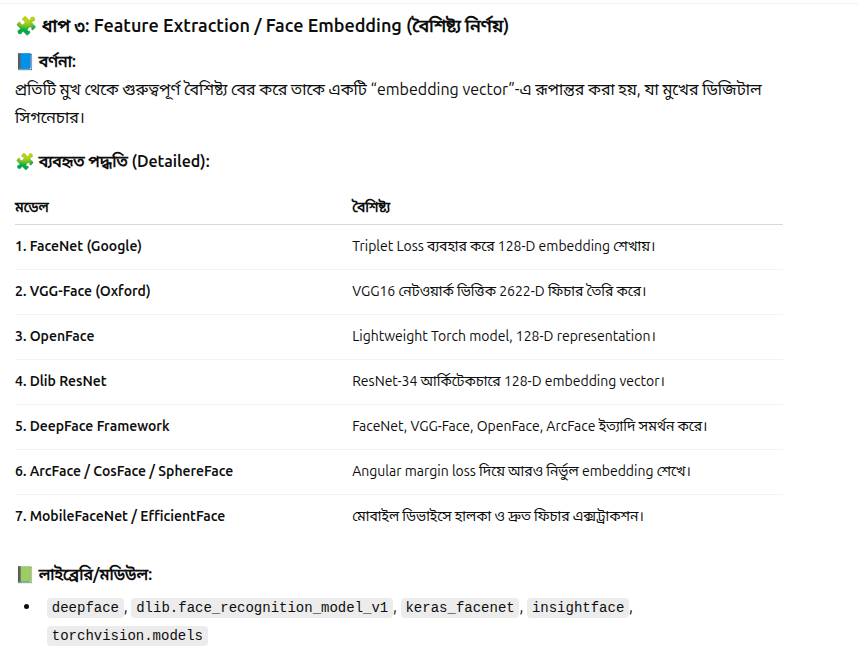

In [3]:
import os
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.preprocessing import Normalizer
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------
# 1️⃣ FaceNet Embedding Function
# -----------------------------
def get_face_embedding(model, face_img):
    """
    🧩 FaceNet Feature Extraction
    -------------------------------
    face_img: RGB face image
    return: 128-D embedding vector
    """
    face = cv2.resize(face_img, (160, 160))
    face = face.astype('float32') / 255.0
    mean, std = face.mean(), face.std()
    face = (face - mean) / std
    face = np.expand_dims(face, axis=0)
    embedding = model.predict(face)
    return embedding[0]

# -----------------------------
# 2️⃣ Load pretrained FaceNet model (.h5)
# -----------------------------
model = load_model('facenet_keras.h5', safe_mode=False)
print("✅ FaceNet model loaded.")

# -----------------------------
# 3️⃣ Prepare dataset embeddings
# -----------------------------
dataset_path = 'dataset/train'  # folder structure: train/person_name/*.jpg
embeddings_db = {}
for person_name in os.listdir(dataset_path):
    person_dir = os.path.join(dataset_path, person_name)
    if not os.path.isdir(person_dir):
        continue
    person_embeddings = []
    for img_name in os.listdir(person_dir):
        img_path = os.path.join(person_dir, img_name)
        img = cv2.imread(img_path)
        rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        embedding = get_face_embedding(model, rgb_img)
        person_embeddings.append(embedding)
    # Store average embedding per person
    embeddings_db[person_name] = np.mean(person_embeddings, axis=0)
print("✅ Dataset embeddings prepared.")

# Normalize embeddings for cosine similarity
l2_normalizer = Normalizer('l2')
for k in embeddings_db.keys():
    embeddings_db[k] = l2_normalizer.transform([embeddings_db[k]])[0]

# -----------------------------
# 4️⃣ Test unknown face
# -----------------------------
test_image_path = 'dataset/test/ronaldo/ronaldo.jpg'
img = cv2.imread(test_image_path)
rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
test_embedding = get_face_embedding(model, rgb_img)
test_embedding = l2_normalizer.transform([test_embedding])[0]

# -----------------------------
# 5️⃣ Compare with database
# -----------------------------
best_match = None
best_score = -1  # Cosine similarity [-1,1]

for name, db_embedding in embeddings_db.items():
    score = cosine_similarity([test_embedding], [db_embedding])[0][0]
    if score > best_score:
        best_score = score
        best_match = name

# -----------------------------
# 6️⃣ Result
# -----------------------------
print(f"🔹 Best Match: {best_match}")
print(f"🔹 Cosine Similarity: {best_score:.4f}")

# -----------------------------
# 7️⃣ Display Image with Name
# -----------------------------
cv2.putText(img, f"{best_match} ({best_score:.2f})", (10, 30), 
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
cv2.imshow("Face Recognition", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

EOFError: EOF read where object expected